In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [2]:
df = pd.read_csv('Banknote-authentication.csv')
df.head()

,V1,V2
0,3.62160,8.6661
1,4.54590,8.1674
2,3.86600,-2.6383
3,3.45660,9.5228
4,0.32924,-4.4552


In [3]:
df.shape

(1372, 2)

In [6]:
df.describe()

,V1,V2
count,1372.000000,1372.000000
mean,0.433735,1.922353
std,2.842763,5.869047
min,-7.042100,-13.773100
25%,-1.773000,-1.708200
50%,0.496180,2.319650
75%,2.821475,6.814625
max,6.824800,12.951600


In [7]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(df.to_numpy())
print(X.mean(0), X.std(0))

[-8.28621266e-17 -4.14310633e-17] [1. 1.]


In [10]:
#plt.scatter(df.V1, df.V2)

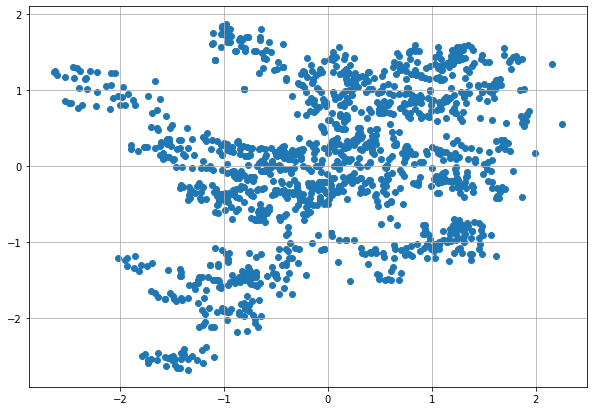

In [9]:
plt.figure(figsize=(10,7))
plt.scatter(X[:,0], X[:,1])
plt.grid()
plt.show()

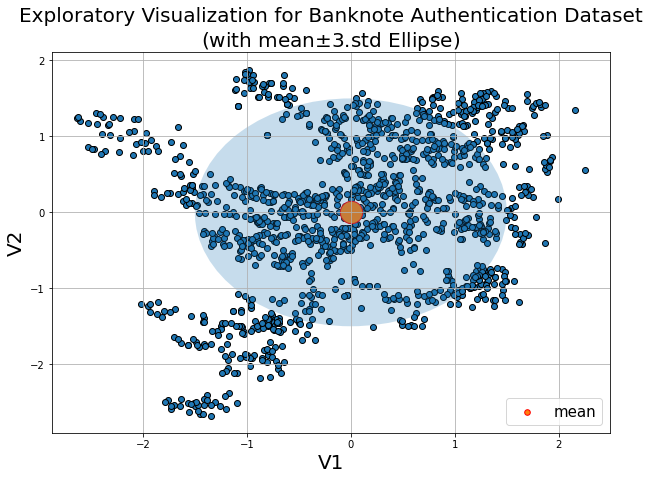

In [36]:
import matplotlib.patches as patches
mean, std = X.mean(0), X.std(0)
e = patches.Ellipse([mean[0], mean[1]], 3*std[0], 3*std[1], alpha=0.25)
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(X[:,0], X[:,1], edgecolor='k')
ax.scatter(mean[0], mean[1], s=500, edgecolor='r', label='mean')
ax.add_patch(e)
plt.xlabel('V1', size=20)
plt.ylabel('V2', size=20)
plt.title('Exploratory Visualization for Banknote Authentication Dataset\n' 
          r'(with mean$\pm$3.std Ellipse)', size=20)
plt.legend(loc='lower right', markerscale=.25, fontsize=15)
plt.grid()
plt.show()

In [90]:
from sklearn.cluster import KMeans
rnd = np.random.randint(1, 100)
print(rnd)
km_res = KMeans(n_clusters=2, init='k-means++', random_state=rnd).fit(X) # 'random'
cls = km_res.cluster_centers_
cls

67


array([[-0.8552756 , -0.63006359],
       [ 0.65494078,  0.48248113]])

In [98]:
labels = km_res.fit_predict(X).tolist()
colors = {0: 'red', 1:'green'}

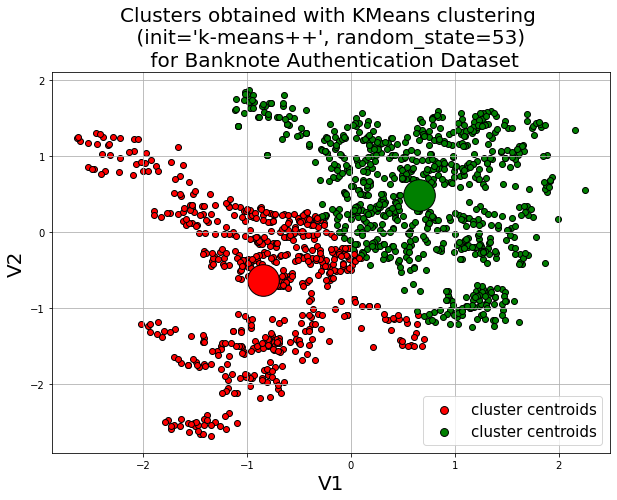

In [87]:
plt.figure(figsize=(10,7))
for i in range(X.shape[0]):
    plt.scatter(X[i,0], X[i,1], color=colors[labels[i]], edgecolor='k')
for i in range(cls.shape[0]):
    plt.scatter(cls[i,0], cls[i,1], s=1000, color=colors[i], edgecolor='k', label='cluster centroids') #KMeans cluster centroids
plt.xlabel('V1', size=20)
plt.ylabel('V2', size=20)
plt.title('Clusters obtained with KMeans clustering \n (init=\'k-means++\', random_state={}) \n for Banknote Authentication Dataset'.format(rnd), size=20) #k-means++
plt.grid()
plt.legend(loc='lower right', markerscale=.25, fontsize=15)
plt.show()

In [105]:
len(list(filter(lambda x: x == 0, labels))), len(list(filter(lambda x: x == 1, labels)))

(597, 775)

**KMeans clustering to find the genuine and fake Bank Notes**

**Description**

* As can be seen from the figures, the result of the k-means clustering with different initializations (using different random states with scikit-learn) is pretty stable, final coordinates of the two cluster centroids are around

   * (-0.8552756, -0.63006359)
   * (0.65494078, 0.48248113)
 
* K-Means clustering creates 2 clusters, one on left and the another one on right, with 597 points and 775 points, respectively.

In [6]:
df.describe()

,V1,V2
count,1372.000000,1372.000000
mean,0.433735,1.922353
std,2.842763,5.869047
min,-7.042100,-13.773100
25%,-1.773000,-1.708200
50%,0.496180,2.319650
75%,2.821475,6.814625
max,6.824800,12.951600


**Brief description of the dataset**

* The dataset has 1372 datapoints (rows) and 2 columns, namely **V1** and **V2** (it is 2 dimensional).
* The **mean** value of the first feature (column) **V1** is 0.433735. The **standard deviation** is 2.842763. The **maximum** and **minimum** values are 6.824800 and -7.042100, respectively, for this column.
* The **mean** value of the second feature (column) **V2** is 1.922353. The **standard deviation** is 5.869047. The **maximum** and **minimum** values are 12.951600 and -13.773100, respectively, for this column.

**Evaluation of its suitability for K-Means clustering**

* The 2-dimensional dataset has enough datapoints (namely 1372) to train the KMeans algorithm on.
* However, the scale of the features V1 and V2 are different. So, it's better to standardize (e.g., z-score normalize) the data prior to running KMeans on it, so that none of the features dominate over the other.
* Finally, the shape of the data is not spherical / circular and it may not be ideal for KMeans clustering to find the clusters with high accuracy.
* Also, as can be seen from the figure, there are many outliers in the dataset (outside mean$\pm$3.std ellipse). The outliers may have negative impacts on the accuracy of KMeans, since KMeans relies on the distance (using Euclidean distance metric) from the centroid (mean) of the clusters, and outliers have strong impact on the mean.

Brief description of the dataset
The dataset has 1372 datapoints (rows) and 2 columns, namely V1 and V2 (it is 2 dimensional).
The mean value of the first feature (column) V1 is 0.433735. The standard deviation is 2.842763. The maximum and minimum values are 6.824800 and -7.042100, respectively, for this column.
The mean value of the second feature (column) V2 is 1.922353. The standard deviation is 5.869047. The maximum and minimum values are 12.951600 and -13.773100, respectively, for this column.
Evaluation of its suitability for K-Means clustering
The 2-dimensional dataset has enough datapoints (namely 1372) to train the KMeans algorithm on.
However, the scale of the features V1 and V2 are different. So, it's better to standardize (e.g., z-score normalize) the data prior to running KMeans on it, so that none of the features dominate over the other.
We need to find two clusters in the dataset (and use them to do the binary classification) using KMeans. The data seems to have 2 (vertically separated) clusters (a big upper one and a smaller lower one), and if the centroids are initialized properly, KMeans should be able to find the clusters.
However, the shape of the data is not spherical / circular and it is not ideal for KMeans clustering to find the clusters with high accuracy (density based clustering or spectral clustering can do a better job here).
Finally, as can be seen from the figure, there are many outliers in the dataset (outside mean±±3.std ellipse). The outliers may have negative impacts on the accuracy of KMeans, since KMeans relies on the distance (using Euclidean distance metric) from the centroid (mean) of the clusters, and outliers have strong impact on the mean.
